# Comparying density layers between panan0025 runs for stiching

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
import cf_xarray as cf
# need to install opencv-python for this:
import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio
import glob
import imageio.v3 as iio
import cmocean.cm as cm

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [2]:
client = Client(threads_per_worker = 1)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

## I - Stiching data and saving it

I will first stich the data and save it so I already make the movies with the proper saved files

In [3]:
#change directories here
time_slice=slice('2000-11-01',None)

chunks0 = {
    "time": 1,       # operate per timestep
    "rho2_l": 3,     # split depth in half to balance compute
    "yh": 800,       # roughly split 3383 → 5 chunks
    "xq": 14401,     # keep full x dimension for contiguous access
    "yq": 800,
    "xh": 14400
}

#Import all files again without cutting lat
OLD0025_ρ = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ocean_daily_rho2_2000*.nc',chunks=chunks0).sel(time=time_slice)
NEW0025_ρ = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/*ocean_daily_rho2_2000*.nc',chunks=chunks0).sel(time=time_slice)
#the full old run
OLD0025_ρ_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ocean_daily_rho2_2000*.nc',chunks=chunks0)
#AREACELLO
area = xr.open_dataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/20001101.ocean_static.nc',chunks=chunks0).areacello

In [4]:
#Creating the xarray that will be modified
ρ_stiched = OLD0025_ρ.copy()

#weights = np.append(np.linspace(9,2,20),np.linspace(1.9,0,28)) #old weigthing strategy, applied only in the merged period
weights = np.append(np.linspace(10,1.5,32),np.linspace(1.4,0,48)) #new weighting, applied over the whole period. It will be applied from the 4th timestamp one
weights = np.append(np.linspace(10,1.9,32),np.linspace(1.7,0,48)) #new weighting, applied over the whole period. It will be applied from the 4th timestamp one
weights

array([10.        ,  9.73870968,  9.47741935,  9.21612903,  8.95483871,
        8.69354839,  8.43225806,  8.17096774,  7.90967742,  7.6483871 ,
        7.38709677,  7.12580645,  6.86451613,  6.60322581,  6.34193548,
        6.08064516,  5.81935484,  5.55806452,  5.29677419,  5.03548387,
        4.77419355,  4.51290323,  4.2516129 ,  3.99032258,  3.72903226,
        3.46774194,  3.20645161,  2.94516129,  2.68387097,  2.42258065,
        2.16129032,  1.9       ,  1.7       ,  1.66382979,  1.62765957,
        1.59148936,  1.55531915,  1.51914894,  1.48297872,  1.44680851,
        1.4106383 ,  1.37446809,  1.33829787,  1.30212766,  1.26595745,
        1.22978723,  1.19361702,  1.15744681,  1.1212766 ,  1.08510638,
        1.04893617,  1.01276596,  0.97659574,  0.94042553,  0.90425532,
        0.86808511,  0.83191489,  0.79574468,  0.75957447,  0.72340426,
        0.68723404,  0.65106383,  0.61489362,  0.5787234 ,  0.54255319,
        0.50638298,  0.47021277,  0.43404255,  0.39787234,  0.36

Testing cutoff value for volcello

In [5]:
area = xr.open_dataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/20001101.ocean_static.nc',chunks=chunks0).areacello
Newstiched0025_ρ_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension_sitched/output138_sitched/*ocean_daily_rho2_2000*.nc',chunks=chunks0)
dzt0025_new = Newstiched0025_ρ_full.volcello/area
#layer depths
volfilter = 100
hthick_new = dzt0025_new[:,::-1,:,:].cumsum('rho2_l')[:,::-1,:,:]
hthick_new0f = hthick_new.where(hthick_new>volfilter)

hthick_new0f = hthick_new.where(hthick_new>volfilter)
hthick_new0f_mask = (hthick_new0f*0)+1
hthick_new0f_cumsum = hthick_new0f.cumsum('rho2_l')
hthick_new0f_cumsum = hthick_new0f_cumsum.where(hthick_new0f_cumsum>=0) * hthick_new0f_mask #
depth = xr.open_dataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/20001101.ocean_static.nc',chunks=chunks0).deptho
shelf_mask = depth.fillna(0); shelf_mask=shelf_mask.where(shelf_mask==0)



Text(0.5, 1.0, '2000-10-29 07:30')

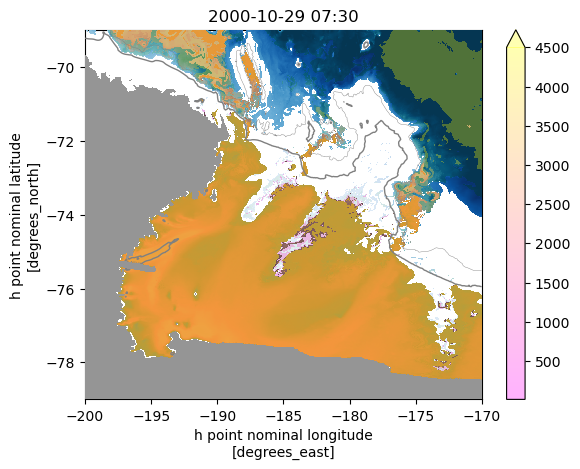

In [6]:
t=10
ylims = slice(-79,-69)
xlims= slice(-200,-170)

Dmax = 4500

hthick_new0f_cumsum2=hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=3)
timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=1).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Blues',add_colorbar=False)
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=2).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Greens',add_colorbar=False,alpha=0.3)
hthick_new0f_cumsum2.plot(vmin=10,vmax=Dmax,zorder=20,cmap='spring',alpha=0.3)

hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=4).plot(vmin=10,vmax=Dmax,zorder=20,cmap='copper',add_colorbar=False,alpha=0.7)
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=5).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Wistia',add_colorbar=False,alpha=0.5)
shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
plt.ylim(-79,-69)
plt.xlim(-200,-170)
plt.title(timestamp_new )


In [7]:
# %%time 

#Old stitching method, only for aligned periods


# # recalculating the newlayers, but without any latitude cut
# ρ_stiched['volcello'] = ρ_stiched['volcello'] * np.nan

# for t in range(len(OLD0025_ρ.time)):
#     ρ_stiched['volcello'][t,:,:,:] =  (( (OLD0025_ρ.volcello.isel(time=t)*weights[t]) + (NEW0025_ρ.volcello.isel(time=t)))/(weights[t]+1))


# # recalculating the newlayers, but without any latitude cut
# ρ_stiched['h_rho'] = ρ_stiched['h_rho'] * np.nan
# for t in range(len(OLD0025_ρ.time)):
#     ρ_stiched['h_rho'][t,:,:,:] =  (( (OLD0025_ρ.h_rho.isel(time=t)*weights[t]) + (NEW0025_ρ.h_rho.isel(time=t)))/(weights[t]+1))


# # recalculating the newlayers, but without any latitude cut
# ρ_stiched['vo'] = ρ_stiched['vo'] * np.nan
# for t in range(len(OLD0025_ρ.time)):
#     ρ_stiched['vo'][t,:,:,:] =  (( (OLD0025_ρ.vo.isel(time=t)*weights[t]) + (NEW0025_ρ.vo.isel(time=t)))/(weights[t]+1))


# # recalculating the newlayers, but without any latitude cut
# ρ_stiched['uo'] = ρ_stiched['uo'] * np.nan
# for t in range(len(OLD0025_ρ.time)):
#     ρ_stiched['uo'][t,:,:,:] =  (( (OLD0025_ρ.uo.isel(time=t)*weights[t]) + (NEW0025_ρ.uo.isel(time=t)))/(weights[t]+1))




# #stiching
# ρ0025_full_sitched = OLD0025_ρ_full.copy()
# #volcello
# ρ0025_full_sitched['volcello'][(80-48):,:,:,:] = ρ_stiched['volcello']
# #h_rho
# ρ0025_full_sitched['h_rho'][(80-48):,:,:,:] = ρ_stiched['h_rho']
# #uo
# ρ0025_full_sitched['uo'][(80-48):,:,:,:] = ρ_stiched['uo']
# #vo
# ρ0025_full_sitched['vo'][(80-48):,:,:,:] = ρ_stiched['vo']

In [8]:
%%time
######## REDO IT APPLYING A 30 MIN DZT FILTER
# recalculating the newlayers, but without any latitude cut
ρ_stiched= OLD0025_ρ_full.copy()

# propagating new dataset first timestamp into 32 time instances to replace in expanded data for averaging
ref_time = OLD0025_ρ_full.time.isel(time=slice(0,32))
new_init = NEW0025_ρ.isel(time=0).expand_dims(time=ref_time)
NEW0025_ρ_full=xr.concat([new_init, NEW0025_ρ.sel(time=slice(None,'2000-11-06'))], dim="time")

volcut0=250 ##treshold for cutting volume for a rpegressive retreat of densiity layer edgies
volcut=volcut0

for t in range(4,len(ρ_stiched.time)):
    ρ_stiched['volcello'][t,:,:,:] =  (( (OLD0025_ρ_full.volcello.isel(time=t)*weights[t]) + (NEW0025_ρ_full.volcello.isel(time=t)))/(weights[t]+1))
    area0 = ρ_stiched['volcello'][t,:,:,:]/area
    ρ_stiched['volcello'][t,:,:,:] =  ρ_stiched['volcello'][t,:,:,:].where((area0>volcut) | ρ_stiched['volcello'][t,:,:,:].isnull(), 0) #chopping edges smoothly
    #volcut = volcut0 + ((10/80)*t)


# #ρ_stiched['volcello'] = ρ_stiched['volcello'].where((area0>volcut) | ρ_stiched['volcello'].isnull(), 0) #chopping edges smoothly


CPU times: user 27min 55s, sys: 14.7 s, total: 28min 10s
Wall time: 28min 1s


In [9]:
hcut=100

for t in range(4,len(ρ_stiched.time)):
    ρ_stiched['h_rho'][t,:,:,:] =  (( (OLD0025_ρ_full.h_rho.isel(time=t)*weights[t]) + (NEW0025_ρ_full.h_rho.isel(time=t)))/(weights[t]+1))
ρ_stiched['h_rho'] = ρ_stiched['h_rho'].where((ρ_stiched['h_rho']>hcut) | ρ_stiched['h_rho'].isnull(), 0) #chopping edges smoothly

In [ ]:
%%time
for t in range(4,len(ρ_stiched.time)):
    ρ_stiched['uo'][t,:,:,:] =  (( (OLD0025_ρ_full.uo.isel(time=t)*weights[t]) + (NEW0025_ρ_full.uo.isel(time=t)))/(weights[t]+1))

In [ ]:
%%time
for t in range(4,len(ρ_stiched.time)):
    ρ_stiched['vo'][t,:,:,:] =  (( (OLD0025_ρ_full.vo.isel(time=t)*weights[t]) + (NEW0025_ρ_full.vo.isel(time=t)))/(weights[t]+1))

Saving files

In [ ]:
stiched_dir = '/scratch/oz91/wf4500/panan_Hifreq_formovies_extension_sitched/output138_sitched_v250/'

In [ ]:
#setting the files directory for specifying file names
files = sorted(glob.glob('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ocean_daily_rho2_2000*.nc'))


In [ ]:
%%time
#loop through 
for t in range(len(files)):
    data_orig = xr.open_dataset(files[t])
    time_target = data_orig.time[0].item().strftime('%Y-%m-%d')
    ρ_stiched_day = ρ_stiched.sel(time=time_target) # ρ_stiched or ρ0025_full_sitched
    savedir = stiched_dir + files[t][85:]
    #saving file
    ρ_stiched_day.to_netcdf(savedir)
    print(time_target)


## II - Visual check up and short movie production

In [3]:
#importing stictched and old data

chunks0 = {
    "time": 1,       # operate per timestep
    "rho2_l": 3,     # split depth in half to balance compute
    "yh": 800,       # roughly split 3383 → 5 chunks
    "xq": 14401,     # keep full x dimension for contiguous access
    "yq": 800,
    "xh": 14400
}


OLD0025_ρ_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies/wf4500/mom6/archive/mom6-panan/output138/*ocean_daily_rho2_2000*.nc',chunks=chunks0)
Newstiched0025_ρ_full = xr.open_mfdataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension_sitched/output138_sitched/*ocean_daily_rho2_2000*.nc',chunks=chunks0)
depth = xr.open_dataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/20001101.ocean_static.nc',chunks=chunks0).deptho
shelf_mask = depth.fillna(0); shelf_mask=shelf_mask.where(shelf_mask==0)
area = xr.open_dataset('/scratch/oz91/wf4500/panan_Hifreq_formovies_extension/wf4500/mom6/archive/mom6-panan/output138/20001101.ocean_static.nc',chunks=chunks0).areacello

#calculating dzt 
dzt0025_old = OLD0025_ρ_full.volcello/area
dzt0025_new = Newstiched0025_ρ_full.volcello/area

In [4]:
#old_hrho
h_rho_monthly = dzt0025_old.where(dzt0025_old>0)
h_rho_monthly_mask = (h_rho_monthly*0)+1
h_rho_monthly_cumsum = h_rho_monthly.cumsum('rho2_l')
h_rho_monthly_cumsum = h_rho_monthly_cumsum.where(h_rho_monthly_cumsum>0) * h_rho_monthly_mask

#new h_rho
h_rho_monthly_new = dzt0025_new.where(dzt0025_new>0)
h_rho_monthly_mask_new = (h_rho_monthly_new*0)+1
h_rho_monthly_cumsum_new = h_rho_monthly_new.cumsum('rho2_l')
h_rho_monthly_cumsum_new = h_rho_monthly_cumsum_new.where(h_rho_monthly_cumsum_new>0) * h_rho_monthly_mask_new


In [5]:
#layer depths
hthick_old = dzt0025_old[:,::-1,:,:].cumsum('rho2_l')[:,::-1,:,:]
hthick_old0f = hthick_old.where(hthick_old>0)

hthick_new = dzt0025_new[:,::-1,:,:].cumsum('rho2_l')[:,::-1,:,:]
hthick_new0f = hthick_new.where(hthick_new>0)

In [6]:
hthick_old0f = hthick_old.where(hthick_old>0)
hthick_old0f_mask = (hthick_old0f*0)+1
hthick_old0f_cumsum = hthick_old0f.cumsum('rho2_l')
hthick_old0f_cumsum = hthick_old0f_cumsum.where(hthick_old0f_cumsum>0) * hthick_old0f_mask

In [7]:
hthick_new0f = hthick_new.where(hthick_new>0)
hthick_new0f_mask = (hthick_new0f*0)+1
hthick_new0f_cumsum = hthick_new0f.cumsum('rho2_l')
hthick_new0f_cumsum = hthick_new0f_cumsum.where(hthick_new0f_cumsum>0) * hthick_new0f_mask

Text(0.5, 1.0, '2000-11-06 16:30')

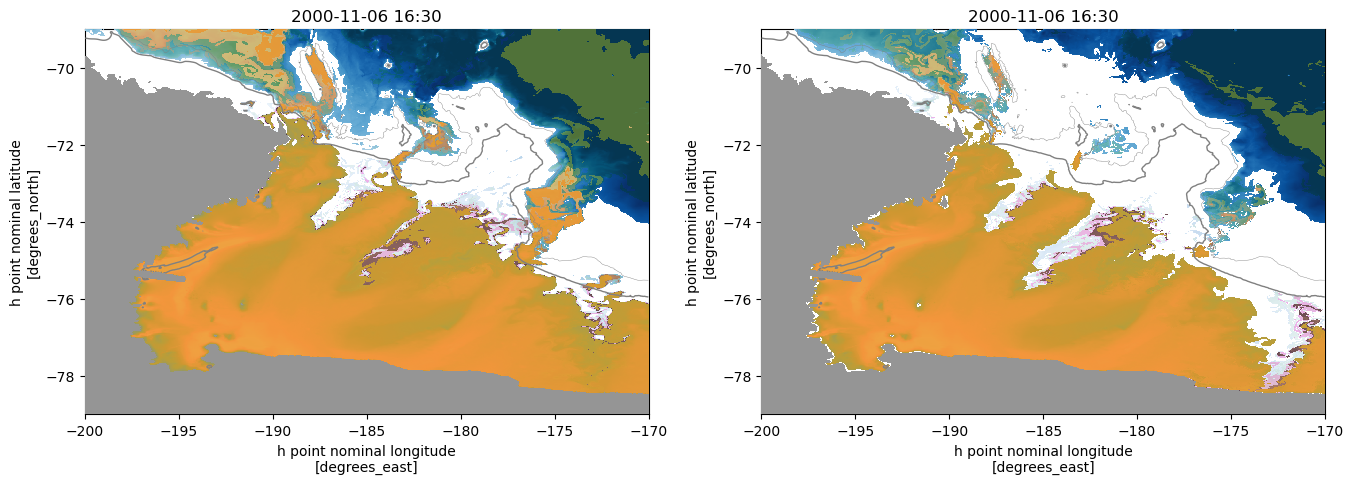

In [8]:
t=-3
plt.figure(figsize=(16,5))
plt.subplots_adjust(hspace=0.4)
ylims = slice(-79,-69)
xlims= slice(-200,-170)

Dmax = 4500

plt.subplot(1,2,1)
timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=1).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Blues',add_colorbar=False)
hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=2).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Greens',add_colorbar=False,alpha=0.3)
hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=3).plot(vmin=10,vmax=Dmax,zorder=20,cmap='spring',add_colorbar=False,alpha=0.3)
hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=4).plot(vmin=10,vmax=Dmax,zorder=20,cmap='copper',add_colorbar=False,alpha=0.7)
hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=5).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Wistia',add_colorbar=False,alpha=0.5)
shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
plt.ylim(-79,-69)
plt.xlim(-200,-170)
plt.title(timestamp_old)


plt.subplot(1,2,2)
timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=1).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Blues',add_colorbar=False)
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=2).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Greens',add_colorbar=False,alpha=0.3)
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=3).plot(vmin=10,vmax=Dmax,zorder=20,cmap='spring',add_colorbar=False,alpha=0.3)
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=4).plot(vmin=10,vmax=Dmax,zorder=20,cmap='copper',add_colorbar=False,alpha=0.7)
hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=5).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Wistia',add_colorbar=False,alpha=0.5)
shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
plt.ylim(-79,-69)
plt.xlim(-200,-170)
plt.title(timestamp_new )


Text(0.5, 1.0, '2000-11-06 22:30')

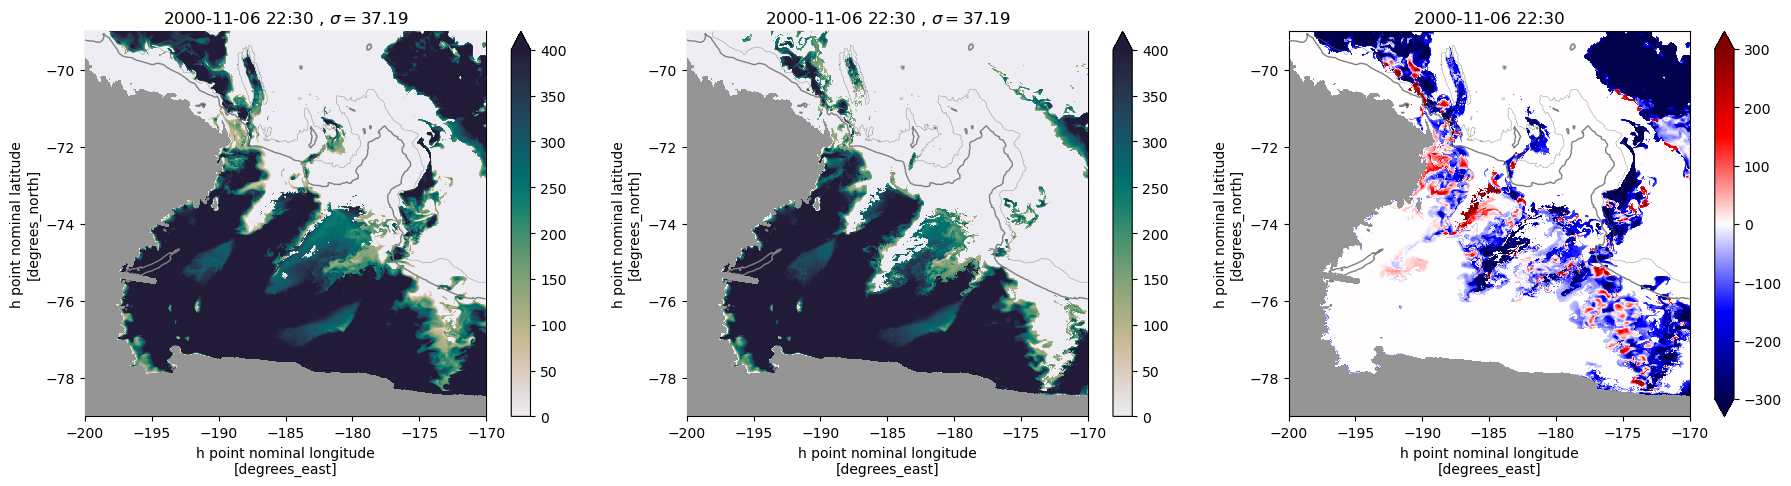

In [9]:
plt.figure(figsize=(22,5))
plt.subplots_adjust(hspace=0.4)
ylims = slice(-79,-69)
xlims= slice(-200,-170)
t=-1
lv=3

layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
plt.subplot(1,3,1)
timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
hthick_old.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
plt.ylim(-79,-69)
plt.xlim(-200,-170)
plt.title(timestamp_old + r' , $\sigma=$' + layern )


plt.subplot(1,3,2)
timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
hthick_new.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
plt.ylim(-79,-69)
plt.xlim(-200,-170)
plt.title(timestamp_new + r' , $\sigma=$' + layern )


plt.subplot(1,3,3)
depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=20,linewidths=[1,.3])
(hthick_new.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims) - hthick_old.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims)).plot(vmin=-300,vmax=300,cmap='seismic')
shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False)
plt.ylim(-79,-69)
plt.xlim(-200,-170)
plt.title(timestamp_new)


In [10]:
%%time
#Multilayer
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_Sigmas/multilayer/"
lv=3
layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
Dmax = 3500

#Producing images for movie
for t in range(79):
    plt.figure(figsize=(16,5))
    plt.subplots_adjust(hspace=0.4)
    ylims = slice(-79,-69)
    xlims= slice(-200,-170)
    
    layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
    plt.subplot(1,2,1)
    timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
    hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=1).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Blues',add_colorbar=False)
    hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=2).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Greens',add_colorbar=False,alpha=0.3)
    hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=3).plot(vmin=10,vmax=Dmax,zorder=20,cmap='spring',add_colorbar=False,alpha=0.6)
    hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=4).plot(vmin=10,vmax=Dmax,zorder=20,cmap='copper',add_colorbar=False,alpha=0.7)
    hthick_old0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=5).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Wistia',add_colorbar=False,alpha=0.5)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_old)
    
    
    plt.subplot(1,2,2)
    timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
    hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=1).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Blues',add_colorbar=False)
    hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=2).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Greens',add_colorbar=False,alpha=0.3)
    hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=3).plot(vmin=10,vmax=Dmax,zorder=20,cmap='spring',add_colorbar=False,alpha=0.6)
    hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=4).plot(vmin=10,vmax=Dmax,zorder=20,cmap='copper',add_colorbar=False,alpha=0.7)
    hthick_new0f_cumsum.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=5).plot(vmin=10,vmax=Dmax,zorder=20,cmap='Wistia',add_colorbar=False,alpha=0.5)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new )
    
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'_multilevel.png',dpi=300,bbox_inches='tight')
    plt.close()


#creating the movie

frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie_multilayer.mp4",   # use .avi for MPEG4
    frames,
    fps=15,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")


✅ Movie saved successfully (MPEG4 format)
CPU times: user 32min 47s, sys: 14min 11s, total: 46min 58s
Wall time: 54min


I plotted above for the first and last timestep. THis is what we want to plot for the movies

For layer 3

In [11]:
%%time
#creating files for movies
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_Sigmas/layer3/"
lv=3
layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
#Producing images for movie
for t in range(80):
    plt.figure(figsize=(22,5))
    plt.subplots_adjust(hspace=0.4)
    ylims = slice(-79,-69)
    xlims= slice(-200,-170)
    
    
    layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
    plt.subplot(1,3,1)
    timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
    hthick_old.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_old + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,2)
    timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
    hthick_new.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,3)
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=20,linewidths=[1,.3])
    (hthick_new.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims) - hthick_old.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims)).plot(vmin=-300,vmax=300,cmap='seismic')
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new)
    
    
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'_level'+str(lv)+'.png',dpi=300,bbox_inches='tight')
    plt.close()


#creating the movie

frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie_level" + str(lv)+ ".mp4",   # use .avi for MPEG4
    frames,
    fps=15,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")

✅ Movie saved successfully (MPEG4 format)
CPU times: user 14min 58s, sys: 4min 28s, total: 19min 26s
Wall time: 20min 35s


now for level 4

In [12]:
%%time
#creating files for movies
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_Sigmas/layer4/"
lv=4
layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
#Producing images for movie
for t in range(80):
    plt.figure(figsize=(22,5))
    plt.subplots_adjust(hspace=0.4)
    ylims = slice(-79,-69)
    xlims= slice(-200,-170)
    
    
    layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
    plt.subplot(1,3,1)
    timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
    hthick_old.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_old + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,2)
    timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
    hthick_new.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,3)
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=20,linewidths=[1,.3])
    (hthick_new.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims) - hthick_old.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims)).plot(vmin=-300,vmax=300,cmap='seismic')
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new)
    
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'_level'+str(lv)+'.png',dpi=300,bbox_inches='tight')
    plt.close()


#creating the movie

frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie_level" + str(lv)+ ".mp4",   # use .avi for MPEG4
    frames,
    fps=15,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")


✅ Movie saved successfully (MPEG4 format)
CPU times: user 15min 12s, sys: 4min 34s, total: 19min 47s
Wall time: 21min 9s


for level 2

In [13]:
%%time
#creating files for movies
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_Sigmas/layer2/"
lv=2
layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
#Producing images for movie
for t in range(80):
    plt.figure(figsize=(22,5))
    plt.subplots_adjust(hspace=0.4)
    ylims = slice(-79,-69)
    xlims= slice(-200,-170)
    
    
    layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
    plt.subplot(1,3,1)
    timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
    hthick_old.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_old + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,2)
    timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
    hthick_new.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,3)
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=20,linewidths=[1,.3])
    (hthick_new.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims) - hthick_old.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims)).plot(vmin=-300,vmax=300,cmap='seismic')
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new)
    
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'_level'+str(lv)+'.png',dpi=300,bbox_inches='tight')
    plt.close()


#creating the movie

frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie_level" + str(lv)+ ".mp4",   # use .avi for MPEG4
    frames,
    fps=15,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")


✅ Movie saved successfully (MPEG4 format)
CPU times: user 16min 26s, sys: 5min 34s, total: 22min
Wall time: 23min 58s


for level 5

In [14]:
%%time
#creating files for movies
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_Sigmas/layer5/"
lv=5
layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
#Producing images for movie
for t in range(80):
    plt.figure(figsize=(22,5))
    plt.subplots_adjust(hspace=0.4)
    ylims = slice(-79,-69)
    xlims= slice(-200,-170)
    
    
    layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
    plt.subplot(1,3,1)
    timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
    hthick_old.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_old + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,2)
    timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
    hthick_new.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,3)
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=20,linewidths=[1,.3])
    (hthick_new.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims) - hthick_old.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims)).plot(vmin=-300,vmax=300,cmap='seismic')
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new)
    
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'_level'+str(lv)+'.png',dpi=300,bbox_inches='tight')
    plt.close()


#creating the movie

frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie_level" + str(lv)+ ".mp4",   # use .avi for MPEG4
    frames,
    fps=15,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")


✅ Movie saved successfully (MPEG4 format)
CPU times: user 16min 42s, sys: 5min 42s, total: 22min 25s
Wall time: 25min 4s


for level 1

In [15]:
%%time
#creating files for movies
files_dir = "/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Jupyter/Movies_Sigmas/layer1/"
lv=1
layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
#Producing images for movie
for t in range(80):
    plt.figure(figsize=(22,5))
    plt.subplots_adjust(hspace=0.4)
    ylims = slice(-79,-69)
    xlims= slice(-200,-170)
    
    
    layern = str(np.round(hthick_old0f.rho2_l[lv]-1000,2).values)
    plt.subplot(1,3,1)
    timestamp_old = hthick_old0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21, linewidths=[1,.3])
    hthick_old.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_old + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,2)
    timestamp_new = hthick_new0f.isel(time=t).time.item().strftime('%Y-%m-%d %H:%M')
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=21 ,linewidths=[1,.3])
    hthick_new.sel(xh=xlims,yh=ylims).isel(time=t,rho2_l=lv).plot(vmin=0,vmax=400,zorder=20,cmap=cm.rain)
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False,zorder=23)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new + r' , $\sigma=$' + layern )
    
    
    plt.subplot(1,3,3)
    depth.sel(xh=xlims,yh=ylims).plot.contour(levels=[1000,2000],colors='grey',zorder=20,linewidths=[1,.3])
    (hthick_new.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims) - hthick_old.isel(time=t,rho2_l=lv).sel(xh=xlims,yh=ylims)).plot(vmin=-300,vmax=300,cmap='seismic')
    shelf_mask.sel(xh=xlims,yh=ylims).plot(cmap='Greys',add_colorbar=False)
    plt.ylim(-79,-69)
    plt.xlim(-200,-170)
    plt.title(timestamp_new)
    
    plt.savefig(files_dir+'movie_figs_'+str(t).zfill(2)+'_level'+str(lv)+'.png',dpi=300,bbox_inches='tight')
    plt.close()


#creating the movie

frames = []
for file in sorted(glob.glob(files_dir + "movie_*.png")):
    img = iio.imread(file)
    if img.shape[-1] == 4:
        img = img[..., :3]  # strip alpha
    frames.append(img)

iio.imwrite(
    files_dir + "Joined_Movie_level" + str(lv)+ ".mp4",   # use .avi for MPEG4
    frames,
    fps=15,
    codec="mpeg4"                     # <-- this one will work
)

print("✅ Movie saved successfully (MPEG4 format)")


✅ Movie saved successfully (MPEG4 format)
CPU times: user 17min 48s, sys: 6min 24s, total: 24min 12s
Wall time: 27min 7s
